<h1 style="text-align:center;">Numerical Methods for <br>Stochastic Differential Equations<br></h1>
<div style="text-align:center;">Ariel Kalingking</div>
<div style="text-align:center;">akalingking@gmail.com</div>
<p style="text-align:center;">Appendix: Python Code</p>

In [30]:
import math
import numpy as np
import statsmodels.api as sm
import logging
import matplotlib
import matplotlib.pyplot as plt

random_seed = 14
plt_inline_enable = False
imagepath = "../paper/figures/"
figsize = (4,3)
fontbig = 8
fontmed = 7
fontsmall = 6

matplotlib.use('TkAgg')
logging.getLogger().setLevel(logging.ERROR)
if plt_inline_enable:
    %matplotlib inline

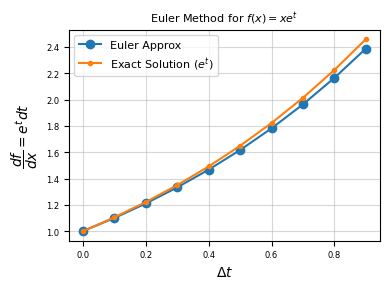

In [31]:
## Compare analytical solution to Euler approximation on ODE
# f(x)  = xe^t
# df/dx = e^tdt
def dfdx(t):
    return np.exp(t)

# Parameters
N = 10                # Number of increments
T = 1                 # Time horizon
dt = T/N              # Step size
t = np.arange(0,1,dt) # timesteps
y0 = 1

# Euler approximation
y = np.zeros(N)
y[0] = y0
for i in range(1, N):
    y[i] = y[i-1] + dfdx(t[i-1])*dt

# Exact Solution for comparison: df/dx = e^tdt
y_exp = np.exp(t)

plt.figure(figsize=figsize)
plt.plot(t, y, marker="o", label='Euler Approx')
plt.plot(t, y_exp, marker=".", label='Exact Solution ($e^t$)')
plt.title('Euler Method for $f(x)=xe^t$',fontsize=fontbig)
plt.xlabel('$\Delta t$')
plt.tick_params(axis='both', which='major', labelsize=fontsmall) 
plt.ylabel('$f(x)$')
plt.legend(prop={"size":8})
plt.grid(":", alpha=0.5)
plt.tight_layout()
plt.savefig(imagepath+"/euler_method.pdf")
if plt_inline_enable:
    plt.show()

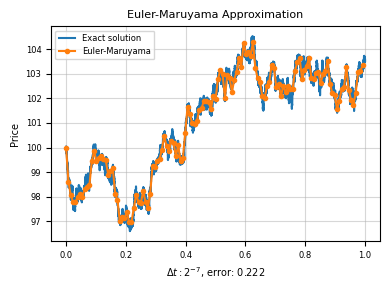

In [32]:
## Compare analytical solution to Euler approximation of SDE
np.random.seed(random_seed)
mu = 0.03      # Drift
sigma = 0.05   # Diffusion
x0 = 100       # Initial price
N = 2**15      # Brownian increments
T = 1          # Time horizon
dt = T/N       # Time step size
W = np.sqrt(dt)*np.random.normal(0, 1, size=N) # Brownian

# Exact solution using Brownian motion with dt
Wt = W.cumsum()
t = np.arange(0, T, dt)
Xt = np.zeros(len(t))
Xt[0] = x0
for i in range(1,len(t)):
    Xt[i] = x0 * np.exp((mu-0.5*sigma**2) * t[i-1] + sigma*Wt[i-1])
    
# Euler-Maruyama approximation
I = 2**7        # Euler increments
step = int(N/I) # Adjusted Brownian increments
Dt = step*dt    # Euler step size
t_e = np.arange(0, T, Dt)
Xe = np.zeros(I)
Xe[0] = x0
# Recalculate to adjusted Euler increments
Wt_e = np.array([np.sum(W[k*step : (k+1)*step]) for k in range(I)])
for i in range(1, len(t_e)):
    Xe[i] = Xe[i-1] * ((1 + mu*Dt + sigma * Wt_e[i-1]).cumprod())

# Calculate discrepancy
error = np.sqrt((Xt[-1] - Xe[-1])**2)

plt.figure(figsize=figsize)
plt.title(r"Euler-Maruyama Approximation", fontsize=fontbig)
plt.plot(t, Xt, label="Exact solution")
plt.plot(t_e, Xe, marker=".", label="Euler-Maruyama")
plt.xlabel("$\Delta t: 2^{-7}$"+", error: {:.3f}".format(error), fontsize=fontmed)
plt.ylabel("$f(x)$", fontsize=fontmed)
plt.tick_params(axis='both', which='major', labelsize=fontsmall) 
plt.legend(loc="best", fontsize=fontsmall)
plt.grid(":", alpha=0.5)
plt.tight_layout()
plt.savefig(imagepath+"euler_maruyama_approximation.pdf", bbox_inches='tight')
if plt_inline_enable:
    plt.show()

In [38]:
def least_square_fit(X, Y):
    """ Utility function to fit the line y = mx + c """
    A = np.vstack([np.log(X), np.ones(len(X))]).T
    y = np.log(Y)
    slope_intercept = np.linalg.lstsq(A, y, rcond=None)[0]
    resid = np.linalg.norm(A.dot(slope_intercept) - y)**2
    return slope_intercept, resid

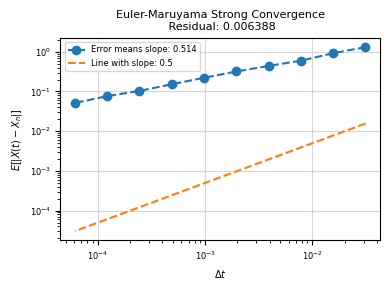

In [39]:
# Euler-Maruyama strong convergence order of 1/2 (Calculation 1)
np.random.seed(random_seed)
mu = 2    # Drift
sigma = 1 # Diffusion
x0 = 1    # Starting price
N = 2**15 # Number of Brownian increments
T = 1     # Time horizon
dt = T/N  # Brownian step size
M = 10**3   # Number of MonteCarlo simulations
errors = np.zeros([M, 10]) # Matrix of errors

for m in range(M):  
    # Execute Monte-Carlo paths
    W = np.sqrt(dt) * np.random.normal(0,1,N)
    Wt = W.cumsum()
    # We only need the terminal value for fast calculation
    Xt = x0 * np.exp((mu - 0.5 * sigma**2)*T + sigma*Wt[-1])
    for i in range(5,15):
        # Analytical solution 
        #t = np.arange(0,T,dt)
        #Xt = np.zeros(N)
        #Xt[0] = x0
        #for j in range(1, len(t)):
        #    Xt[j] = x0 * np.exp((mu-0.5*sigma**2)*t[j-1] + sigma*Wt[j-1])
            
        # Approximation where Dt >= dt
        I = 2**i          # Increments
        step = round(N/I) # Step size adjustment factor
        Dt = step*dt      # Adjusted time step
        te = np.arange(0, T, Dt)
        Wte = np.array([np.sum(W[k*step : (k+1)*step])for k in range(I)])
        Xe = np.zeros(I)
        Xe[0]=x0
        for l in range(1, len(te)):
            Xe[l] = Xe[l-1] * (1 + mu*Dt + sigma*Wte[l-1])
        errors[m, i-5] = np.sqrt((Xt - Xe[-1])**2)

# Vector of Euler time step sizes used as X values and error means as Y values
Dts = np.array([2**x for x in range(-5, -15, -1)])
err_means = errors.mean(axis=0)
lst_sqr_fit, resid = least_square_fit(Dts, err_means)

rho, intercept = lst_sqr_fit
#assert math.isclose(m, 0.5, abs_tol=0.01)

fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.loglog(Dts, err_means, marker="o", linestyle="dashed", label= "Error means slope: {:.3f}".format(rho))
ax.loglog(Dts, 0.5*Dts, linestyle="dashed", label="Line with slope: 0.5")
ax.set_xlabel("$\Delta t$", size=fontmed)
ax.set_ylabel("$E[|X(t)-X_n|]$", size=fontmed)
ax.set_title("Euler-Maruyama Strong Convergence\n" + " Residual: {:.6f}".format(resid), size=fontbig)
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.legend(loc="best", prop={"size":fontsmall})
ax.grid(":", alpha=0.5)

plt.tight_layout()
plt.savefig(imagepath+"euler_maruyama_strong_convergence.pdf", bbox_inches='tight')
if plt_inline_enable:
    plt.show()

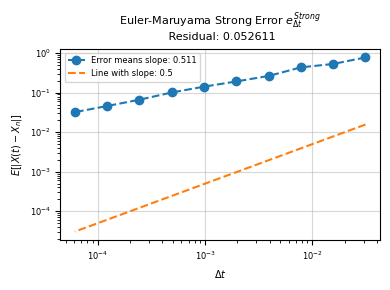

In [40]:
## Euler-Maruyama strong convergence order of 1 (Calculation 2)
# Milstein strong convergence order of 1
mu = 2     # Drift
sigma = 1  # Diffusion
T = 1      # Time horizon
M = 10**3  # Monte-Carlo simulation path
x0 = 1     # Initial value
dt_grid = np.array([2**x for x in range(-5, -15, -1)])
N_dt = len(dt_grid)
err_str = np.zeros(N_dt)

# Run each time delta
for i in range(N_dt):
    Dt = dt_grid[i]
    t = np.arange(Dt, T, Dt)
    N = len(t)
    err_mc = np.zeros(N) 
    
    # Generate Monte-Carlo sample paths
    for m in range(M):
        np.random.seed(m)
        dB = np.sqrt(Dt) * np.random.randn(N)
        B  = np.cumsum(dB)
        # Analytical solution
        Y = x0 * np.exp((mu - 0.5*sigma**2)*t + sigma * B)
        # Euler-Maruyama numerical solution
        Xe = np.zeros(N)
        Xe_cur = x0  # Set initial value
        for n in range(N):    
            Xe_cur = Xe_cur + mu*Xe_cur*Dt + sigma*Xe_cur*dB[n]
            Xe[n] = Xe_cur
        
        err_mc += abs(Y-Xe)        
        
    # Compute mean of absolute errors and find maximum (strong error)
    err_str[i] = max(err_mc/M)

# Fit a linear regression and find the empirical convergence slope
X = sm.add_constant(np.log(dt_grid))
results = sm.OLS(np.log(err_str), X).fit()
convergence_ml = results.params[1]
resid = np.sqrt(results.mse_resid)

fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.loglog(dt_grid, err_str, marker="o", linestyle="dashed",
          label= "Error means slope: {:.3f}".format(convergence_ml))
ax.loglog(dt_grid, 0.5*dt_grid, linestyle="dashed", label="Line with slope: 0.5")
ax.set_xlabel("$\Delta t$", size=fontmed)
ax.set_ylabel("$E[|X(t)-X_n|]$", size=fontmed)
ax.set_title("Euler-Maruyama Strong Error $e_{\Delta t}^{Strong}$\n"
             + " Residual: {:.6f}".format(resid), size=fontbig)
ax.legend(prop={"size":fontsmall})
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.grid(":", alpha=0.5)

plt.tight_layout()
plt.savefig(imagepath+"euler_maruyama_strong_convergence.pdf", bbox_inches='tight')
if plt_inline_enable:
    plt.show()

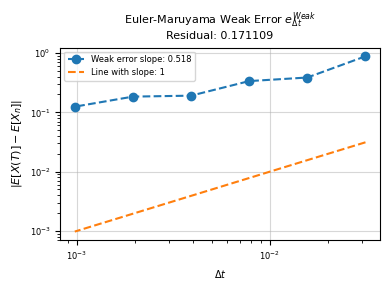

In [28]:
# Euler-Maruyama weak convergence order of 1
np.random.seed(random_seed)
mu = 2            # Drift
sigma = 1         # Diffusion
x0 = 1            # Initial value
N = 2**15         # Number of discrete Brownian increments
T = 1             # Time horizon
dt = T/N          # Step size
M = 10**4         # Monte-Carlo simulation paths
Xe = np.zeros(6)  # Price data array

for i in range(5, 11):
    I = 2**i  # Number of Euler increments
    step = round(N/I)
    Dt = step*dt
    temp = np.zeros((M, I))
    for m in range(M):
        Wt = np.sqrt(Dt) * np.random.normal(0, 1, I)
        temp[m, 0] = x0
        for t in range(1, I):
            temp[m, t] = temp[m, t-1] * (1 + mu*Dt + sigma*Wt[t-1])  
    Xe[i-5] = np.mean(temp[:,-1])
    
weak_errors = np.sqrt((Xe - x0 * np.exp(mu*T))**2)
weak_errors = weak_errors.T

Dts = np.array([2**x for x in range(-5, -11, -1)])
([slope, intercept], residual) = least_square_fit(Dts, weak_errors)

fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.loglog(Dts, abs(weak_errors), marker="o",
          linestyle="dashed", label="Weak error slope: {:.3f}".format(slope))
ax.loglog(Dts, Dts, linestyle="dashed", label="Line with slope: 1")
ax.set_xlabel("$\Delta t$", size=fontmed)
ax.set_ylabel("$|E[X(T)]-E[X_n]|$", size=8)   
ax.set_title("Euler-Maruyama Weak Error $e_{\Delta t}^{Weak}$ \n" 
            + "Residual: {:.6f}".format(residual), size=fontbig)
ax.legend(loc="best", prop={"size":fontsmall})
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.grid(":", alpha=0.5)

plt.tight_layout()
plt.savefig(imagepath+"euler_maruyama_weak_convergence.pdf", bbox_inches='tight')
if plt_inline_enable:
    plt.show()

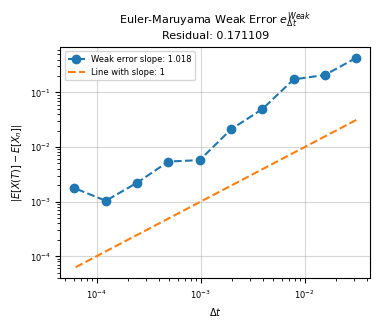

In [36]:
# Euler-Maruyama weak convergence order of 1 (Calculation 2)
mu = 2     # Drift
sigma = 1  # Diffusion
T = 1      # Time horizon
M = 10**3  # Monte-Carlo simulation path
x0 = 1     # Initial value
dt_grid = np.array([2**x for x in range(-5, -15, -1)])
N_dt = len(dt_grid)
err_weak = np.zeros(N_dt)

# Run each time delta
for i in range(N_dt):
    Dt = dt_grid[i]
    t = np.arange(Dt, T, Dt)
    N = len(t)
    # Initiate vectors to store errors and time series
    err_em = np.zeros(N)
    Y_sum = np.zeros(N)
    Xe_sum = np.zeros(N)
    
    # Generate Monte-Carlo sample paths
    for m in range(M):
        np.random.seed(m)
        dB = np.sqrt(Dt) * np.random.randn(N)
        B  = np.cumsum(dB)
        # Analytical solution
        Y = x0 * np.exp((mu - 0.5*sigma**2)*t + sigma * B)
        # Euler-Maruyama numerical solution
        Xe = np.zeros(N)
        Xe_cur = x0  # Set initial value
        for n in range(N):    
            Xe_cur = Xe_cur + mu*Xe_cur*Dt + sigma*Xe_cur*dB[n]
            Xe[n] = Xe_cur
        Y_sum += Y
        Xe_sum += Xe
        
    # Compute mean of absolute errors and find maximum (weak error)
    err_weak[i] = max(abs(Y_sum - Xe_sum)/M)

# Fit a linear regression and find the empirical convergence slope
X = sm.add_constant(np.log(dt_grid))
results = sm.OLS(np.log(err_weak), X).fit()
conv_weak_em = results.params[1]
resid = np.sqrt(results.mse_resid)

fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.loglog(dt_grid, abs(err_weak), marker="o",
          linestyle="dashed", label="Weak error slope: {:.3f}".format(conv_weak_em))
ax.loglog(dt_grid, dt_grid, linestyle="dashed", label="Line with slope: 1")
ax.set_xlabel("$\Delta t$", size=fontmed)
ax.set_ylabel("$|E[X(T)]-E[X_n]|$", size=fontmed)   
ax.set_title("Euler-Maruyama Weak Error $e_{\Delta t}^{Weak}$ \n" 
            + "Residual: {:.6f}".format(residual), size=fontbig)
ax.legend(loc="best", prop={"size":fontsmall})
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.grid(":", alpha=0.5)

plt.savefig(imagepath+"euler_maruyama_weak_convergence.pdf", bbox_inches='tight')
if plt_inline_enable:
    plt.show()

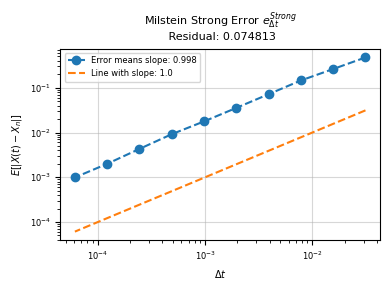

In [29]:
# Milstein strong convergence order of 1
mu = 2     # Drift
sigma = 1  # Diffusion
T = 1      # Time horizon
M = 10**3  # Monte-Carlo simulation path
x0 = 1     # Initial value
dt_grid = np.array([2**x for x in range(-5, -15, -1)])
N_dt = len(dt_grid)
err_str = np.zeros(N_dt)

# Run each time delta
for i in range(N_dt):
    Dt = dt_grid[i]
    t = np.arange(Dt, T, Dt)
    N = len(t)
    # Initiate vectors to store errors and time series
    err_em = np.zeros(N) 
    
    # Generate Monte-Carlo sample paths
    for m in range(M):
        np.random.seed(m)
        dB = np.sqrt(Dt) * np.random.randn(N)
        B  = np.cumsum(dB)
        # Analytical solution
        Y = x0 * np.exp((mu - 0.5*sigma**2)*t + sigma * B)
        # Milstein numerical solution
        Xm = np.zeros(N)
        Xm_cur = x0  # Set initial value
        for n in range(N):    
            Xm_cur = Xm_cur + mu*Xm_cur*Dt + sigma*Xm_cur*dB[n] + 0.5*sigma**2*Xm_cur*(dB[n]**2 - Dt)
            Xm[n] = Xm_cur
        
        err_em += abs(Y-Xm)        
        
    # Compute mean of absolute errors and find maximum (strong error)
    err_str[i] = max(err_em/M)

# Fit a linear regression and find the empirical convergence slope
X = sm.add_constant(np.log(dt_grid))
results = sm.OLS(np.log(err_str), X).fit()
conv_str_ml = results.params[1]
resid = np.sqrt(results.mse_resid)

fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.loglog(dt_grid, err_str, marker="o", linestyle="dashed",
          label= "Error means slope: {:.3f}".format(conv_str_ml))
ax.loglog(dt_grid, dt_grid, linestyle="dashed", 
          label="Line with slope: 1.0")
ax.set_xlabel("$\Delta t$", size=fontmed)
ax.set_ylabel("$E[|X(t)-X_n|]$", size=fontmed)
ax.set_title("Milstein Strong Error $e_{\Delta t}^{Strong}$\n"
             + " Residual: {:.6f}".format(resid), size=fontbig)
ax.legend(loc="best", prop={"size":fontsmall})
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.grid(":", alpha=0.5)
plt.tight_layout()
plt.savefig(imagepath+"milstein_strong_convergence.pdf", bbox_inches='tight')
if plt_inline_enable:
    plt.show()

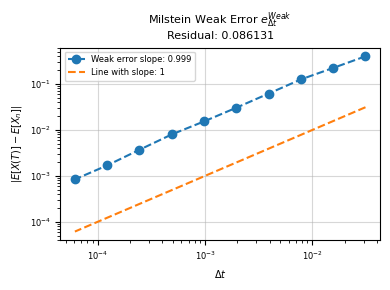

In [37]:
# Milstein weak convergence order of 1 (Calculation 2)
mu = 2     # Drift
sigma = 1  # Diffusion
T = 1      # Time horizon
M = 10**3  # Monte-Carlo simulation path
x0 = 1     # Initial value
dt_grid = np.array([2**x for x in range(-5, -15, -1)])
N_dt = len(dt_grid)
err_weak = np.zeros(N_dt)

for i in range(N_dt):
    # Run each time delta
    Dt = dt_grid[i]
    t = np.arange(Dt, T, Dt)
    N = len(t)
    # Initiate vectors to store errors and time series
    err_em = np.zeros(N)
    Y_sum = np.zeros(N)
    Xm_sum = np.zeros(N)
    
    for m in range(M):
        # Generate Monte-Carlo sample paths
        np.random.seed(m)
        dB = np.sqrt(Dt) * np.random.randn(N)
        B  = np.cumsum(dB)
        # Analytical solution
        Y = x0 * np.exp((mu - 0.5*sigma**2)*t + sigma * B)
        # Milstein numerical solution
        Xm = np.zeros(N)
        Xm_cur = x0  # Set initial value
        for n in range(N):    
            Xm_cur = Xm_cur + mu*Xm_cur*Dt + sigma*Xm_cur*dB[n] + 0.5*sigma**2*Xm_cur*(dB[n]**2 - Dt)
            Xm[n] = Xm_cur
        Y_sum += Y
        Xm_sum += Xm
        
    # Compute mean of absolute errors and find maximum (weak error)
    err_weak[i] = max(abs(Y_sum - Xm_sum)/M)

# Fit a linear regression and find the empirical convergence slope
X = sm.add_constant(np.log(dt_grid))
results = sm.OLS(np.log(err_weak), X).fit()
conv_weak_ml = results.params[1]
resid = np.sqrt(results.mse_resid)

fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.loglog(dt_grid, abs(err_weak), marker="o",
          linestyle="dashed", label="Weak error slope: {:.3f}".format(conv_weak_ml))
ax.loglog(dt_grid, dt_grid, linestyle="dashed", label="Line with slope: 1")
ax.set_xlabel("$\Delta t$", size=fontmed)
ax.set_ylabel("$|E[X(T)]-E[X_n]|$", size=fontmed)   
ax.set_title("Milstein Weak Error $e_{\Delta t}^{Weak}$ \n" 
            + "Residual: {:.6f}".format(resid), size=fontbig)
ax.legend(loc="best", prop={"size":fontsmall})
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.grid(":", alpha=0.5)
                  
plt.tight_layout()
plt.savefig(imagepath+"milstein_weak_convergence.pdf", bbox_inches='tight')
if plt_inline_enable:
    plt.show()